# Test avec Julia

## Premiers tests

In [1]:
function hamiltonian_path(graph, n, dimension, start_node=1)
    """
    This function find a Hamiltonian path in a given graph using backtracking;
    
    Entry : 
    graph (Dict) = a graph where a key is a given node and the value is the list of the connected nodes
    n (int) = the amount of node on a side
    dimension (int) = the dimension of the graph (2 or 3)
    
    Return : 
    path (Vector) = a Hamiltonian path if it exists, otherwise an empty vector
    """

    #dimension should be between 2 and 3
    if dimension == 2
        total_nodes = n * n
    elseif dimension == 3
        total_nodes = n * n * n
    else
        throw(ArgumentError("dimension should be 2 or 3, but $dim has been provided"))
    end

    paths = Vector{Vector{Int}}() # contains all the possible Hamiltonian path
    path = Int[] # contains the current Hamiltion path

    function backtrack(current_node)
        push!(path, current_node)

        if length(path) == total_nodes
            push!(paths, copy(path))
        end

        for neighbor in graph[current_node]
            if neighbor ∉ path
                backtrack(neighbor)
            end
        end

        pop!(path)
    end

    

    # for start_node in keys(graph)
    #     backtrack(start_node)
    # end


    push!(path, start_node)

    if n == 2
        imposed_first_neighbor = start_node + 1
        backtrack(imposed_first_neighbor)

    elseif n == 3
        imposed_first_neighbor  = start_node + 1
        imposed_second_neighbor = start_node + 2

        push!(path, imposed_first_neighbor)
        backtrack(imposed_second_neighbor)
        pop!(path)
    end

    
    return paths
end


hamiltonian_path (generic function with 2 methods)

In [2]:
#One simple 2*2 graph
"""
1--2
|  |
3--4
"""
graph = Dict(
    1 => [2, 3],
    2 => [1, 4],
    3 => [1, 4],
    4 => [2, 3]
)

n = 2

path = hamiltonian_path(graph, n, 2)
println("Hamiltonian paths found: ", path)

Hamiltonian paths found: [[1, 2, 4, 3]]


In [3]:
function create_graph2D(n)
    """
    This function create a graph that represents the links between each node of a 2D lattice;
    Entry : 
    n (int) = the amount of node on a side
    Return : 
    Graph (Dict) = a graph where a key is a given node and the value is the list of the connected nodes
    """
    idx(i,j) = (i-1)*n + j
    graph = Dict{Int, Vector{Int}}()

    for i in 1:n, j in 1:n
        neighbors = Int[]

        if i > 1
            push!(neighbors, idx(i-1,j)) # Up
        end
        if i < n
            push!(neighbors, idx(i+1,j)) # Down
        end
        if j > 1
            push!(neighbors, idx(i,j-1)) # Left
        end
        if j < n
            push!(neighbors, idx(i,j+1)) # Right
        end

        graph[idx(i,j)] = sort!(neighbors)
    end

    return graph
end

create_graph2D (generic function with 1 method)

In [4]:
#test for 2D graph 3*3
n = 3
graph = create_graph2D(n)
print(graph)
print("\n")
path = hamiltonian_path(graph, n, 2)
println("Hamiltonian paths found: ", path)
print("Number of Hamiltonian paths found: ", length(path)) 
# On ne devrait avoir que 3 chemins. 


Dict(5 => [2, 4, 6, 8], 4 => [1, 5, 7], 6 => [3, 5, 9], 7 => [4, 8], 2 => [1, 3, 5], 9 => [6, 8], 8 => [5, 7, 9], 3 => [2, 6], 1 => [2, 4])
Hamiltonian paths found: [[1, 2, 3, 6, 5, 4, 7, 8, 9], [1, 2, 3, 6, 9, 8, 5, 4, 7], [1, 2, 3, 6, 9, 8, 7, 4, 5]]
Number of Hamiltonian paths found: 3

In [5]:
function create_graph3D(n)
    """
    Create a graph representing the links between each node of a 3D lattice.
    Entry:
    n (int) = the amount of node on a side
    Return : 
    Graph (Dict) = a graph where a key is a given node and the value is the list of the connected nodes
    """
    #linear numerotation of nodes 
    idx(i,j,k) = (i-1)*n^2 + (j-1)*n + k
    graph = Dict{Int, Vector{Int}}()

    for i in 1:n, j in 1:n, k in 1:n
        neighbors = Int[]

        #neighbors on x-axis
        if i > 1
            push!(neighbors, idx(i-1,j,k))
        end
        if i < n
            push!(neighbors, idx(i+1,j,k))
        end

        #neighbors on y-axis
        if j > 1
            push!(neighbors, idx(i,j-1,k))
        end
        if j < n
            push!(neighbors, idx(i,j+1,k))
        end

        #neighbors on z-axis
        if k > 1
            push!(neighbors, idx(i,j,k-1))
        end
        if k < n
            push!(neighbors, idx(i,j,k+1))
        end

        graph[idx(i,j,k)] = sort!(neighbors)
    end

    return graph
end


create_graph3D (generic function with 1 method)

In [6]:
#3D graph 2*2*2
n = 2
graph3D = create_graph3D(n)
println(graph3D)
#test for 3D graph 2*2*2
path = hamiltonian_path(graph3D, n, 3)
println("Hamiltonian paths found: ", path)
print("Number of Hamiltonian paths found: ", length(path)) 
# On ne devrait avoir que 5 chemins, [1, 2, 4, 3, 7, 8, 6, 5] et [1, 2, 6, 5, 7, 8, 4, 3] sont identiques par rotation

Dict(5 => [1, 6, 7], 4 => [2, 3, 8], 6 => [2, 5, 8], 7 => [3, 5, 8], 2 => [1, 4, 6], 8 => [4, 6, 7], 3 => [1, 4, 7], 1 => [2, 3, 5])
Hamiltonian paths found: [[1, 2, 4, 3, 7, 5, 6, 8], [1, 2, 4, 3, 7, 8, 6, 5], [1, 2, 4, 8, 6, 5, 7, 3], [1, 2, 6, 5, 7, 3, 4, 8], [1, 2, 6, 5, 7, 8, 4, 3], [1, 2, 6, 8, 4, 3, 7, 5]]
Number of Hamiltonian paths found: 6

In [7]:
#Doesn't work for now, i think they are too many paths, 
n = 3
graph3D = create_graph3D(n)
println(graph3D)

#test for 3D graph 3*3*3
path = hamiltonian_path(graph3D, n, 3)
#println("Hamiltonian paths found: ", path)
print("Number of Hamiltonian paths found: ", length(path))

Dict(5 => [2, 4, 6, 8, 14], 16 => [7, 13, 17, 25], 20 => [11, 19, 21, 23], 12 => [3, 11, 15, 21], 24 => [15, 21, 23, 27], 8 => [5, 7, 9, 17], 17 => [8, 14, 16, 18, 26], 1 => [2, 4, 10], 19 => [10, 20, 22], 22 => [13, 19, 23, 25], 23 => [14, 20, 22, 24, 26], 6 => [3, 5, 9, 15], 11 => [2, 10, 12, 14, 20], 9 => [6, 8, 18], 14 => [5, 11, 13, 15, 17, 23], 3 => [2, 6, 12], 7 => [4, 8, 16], 25 => [16, 22, 26], 4 => [1, 5, 7, 13], 13 => [4, 10, 14, 16, 22], 15 => [6, 12, 14, 18, 24], 2 => [1, 3, 5, 11], 10 => [1, 11, 13, 19], 18 => [9, 15, 17, 27], 21 => [12, 20, 24], 26 => [17, 23, 25, 27], 27 => [18, 24, 26])
Number of Hamiltonian paths found: 67710

In [8]:
path

67710-element Vector{Vector{Int64}}:
 [1, 2, 3, 6, 5, 4, 7, 8, 9, 18  …  16, 25, 22, 19, 20, 21, 24, 23, 26, 27]
 [1, 2, 3, 6, 5, 4, 7, 8, 9, 18  …  16, 25, 22, 19, 20, 21, 24, 27, 26, 23]
 [1, 2, 3, 6, 5, 4, 7, 8, 9, 18  …  16, 25, 22, 19, 20, 23, 26, 27, 24, 21]
 [1, 2, 3, 6, 5, 4, 7, 8, 9, 18  …  16, 25, 22, 23, 26, 27, 24, 21, 20, 19]
 [1, 2, 3, 6, 5, 4, 7, 8, 9, 18  …  16, 25, 26, 23, 22, 19, 20, 21, 24, 27]
 [1, 2, 3, 6, 5, 4, 7, 8, 9, 18  …  16, 25, 26, 27, 24, 21, 20, 19, 22, 23]
 [1, 2, 3, 6, 5, 4, 7, 8, 9, 18  …  16, 25, 26, 27, 24, 21, 20, 23, 22, 19]
 [1, 2, 3, 6, 5, 4, 7, 8, 9, 18  …  16, 25, 26, 27, 24, 23, 22, 19, 20, 21]
 [1, 2, 3, 6, 5, 4, 7, 8, 9, 18  …  20, 19, 22, 25, 16, 17, 26, 27, 24, 21]
 [1, 2, 3, 6, 5, 4, 7, 8, 9, 18  …  20, 21, 24, 27, 26, 17, 16, 25, 22, 19]
 ⋮
 [1, 2, 3, 12, 21, 24, 27, 26, 25, 22  …  16, 17, 18, 9, 8, 5, 6, 15, 14, 11]
 [1, 2, 3, 12, 21, 24, 27, 26, 25, 22  …  16, 17, 18, 15, 6, 9, 8, 5, 14, 11]
 [1, 2, 3, 12, 21, 24, 27, 26, 25, 22  …  4,

## Version fonctionnelle

In [9]:
#bis function just to know the different way to start in the medium layer of a 3*3*3
#So we return every start of path from a specific node of a 3*3 graph
function hamiltonian_path_bis(graph, n, dimension, first_node, second_node)

    #dimension should be between 2 and 3
    if dimension == 2
        total_nodes = n * n
    elseif dimension == 3
        total_nodes = n * n * n
    else
        throw(ArgumentError("dimension should be 2 or 3, but $dim has been provided"))
    end

    paths = Vector{Vector{Int}}() #contains all the possible Hamiltonian path
    path = Int[] #contains the current Hamiltion path

    function backtrack(current_node)
        push!(path, current_node)

        push!(paths, copy(path)) #ici on s'en fiche de ne pas avoir des paths finis

        # if length(path) == total_nodes
        #     push!(paths, copy(path))
        # end

        for neighbor in graph[current_node]
            if neighbor ∉ path
                backtrack(neighbor)
            end
        end

        pop!(path)
    end


    # for start_node in keys(graph)
    #     backtrack(start_node)
    # end


    imposed_first_neighbor = first_node
    imposed_second_neighbor = second_node

    push!(path, imposed_first_neighbor)
    backtrack(imposed_second_neighbor)

    return paths
end

  


hamiltonian_path_bis (generic function with 1 method)

### Creation de graphes et force le début

In [10]:
function create_graph2D_bis()

    #manual mapping of positions
    grid = [
        2   11   20;
        5   14   23;
        8   17   26
    ]

    graph = Dict{Int, Vector{Int}}()

    for i in 1:3, j in 1:3
        node = grid[i, j]
        neighbors = Int[]

        # Up
        if i > 1
            push!(neighbors, grid[i-1, j])
        end

        # Down
        if i < 3
            push!(neighbors, grid[i+1, j])
        end

        # Left
        if j > 1
            push!(neighbors, grid[i, j-1])
        end

        # Right
        if j < 3
            push!(neighbors, grid[i, j+1])
        end

        graph[node] = sort!(neighbors)
    end

    return graph
end


create_graph2D_bis (generic function with 1 method)

In [11]:
n = 3
graph = create_graph2D_bis()
println(graph)

paths_1 = hamiltonian_path_bis(graph, n, 2, 5, 2)
println("Hamiltonian paths found: ", paths_1)
println("Number of Hamiltonian paths found: ", length(paths_1)) 

paths_2 = hamiltonian_path_bis(graph, n, 2, 5, 14)
println("Hamiltonian paths found: ", paths_2)
println("Number of Hamiltonian paths found: ", length(paths_2)) 

#liste exaustive des paths de départ à définir

for path in paths_1
    push!(path, path[end]-1)
end

for path in paths_2
    push!(path, path[end]-1)
end

paths_corner = [[1,2,3,6],[1,2,5]]

paths_final = vcat(paths_1, paths_2, paths_corner)


println("Hamiltonian paths begginings found: ", paths_final)
println("Number of Hamiltonian paths begginings found: ", length(paths_final)) 


Dict(5 => [2, 8, 14], 20 => [11, 23], 2 => [5, 11], 11 => [2, 14, 20], 26 => [17, 23], 14 => [5, 11, 17, 23], 8 => [5, 17], 17 => [8, 14, 26], 23 => [14, 20, 26])
Hamiltonian paths found: [[5, 2], [5, 2, 11], [5, 2, 11, 14], [5, 2, 11, 14, 17], [5, 2, 11, 14, 17, 8], [5, 2, 11, 14, 17, 26], [5, 2, 11, 14, 17, 26, 23], [5, 2, 11, 14, 17, 26, 23, 20], [5, 2, 11, 14, 23], [5, 2, 11, 14, 23, 20], [5, 2, 11, 14, 23, 26], [5, 2, 11, 14, 23, 26, 17], [5, 2, 11, 14, 23, 26, 17, 8], [5, 2, 11, 20], [5, 2, 11, 20, 23], [5, 2, 11, 20, 23, 14], [5, 2, 11, 20, 23, 14, 17], [5, 2, 11, 20, 23, 14, 17, 8], [5, 2, 11, 20, 23, 14, 17, 26], [5, 2, 11, 20, 23, 26], [5, 2, 11, 20, 23, 26, 17], [5, 2, 11, 20, 23, 26, 17, 8], [5, 2, 11, 20, 23, 26, 17, 14]]
Number of Hamiltonian paths found: 23
Hamiltonian paths found: [[5, 14], [5, 14, 11], [5, 14, 11, 2], [5, 14, 11, 20], [5, 14, 11, 20, 23], [5, 14, 11, 20, 23, 26], [5, 14, 11, 20, 23, 26, 17], [5, 14, 11, 20, 23, 26, 17, 8], [5, 14, 17], [5, 14, 17, 8], 

In [12]:
function hamiltonian_path_with_beginning(graph, n, dimension, beginning)
    #dimension should be between 2 and 3
    if dimension == 2
        total_nodes = n * n
    elseif dimension == 3
        total_nodes = n * n * n
    else
        throw(ArgumentError("dimension should be 2 or 3, but $dim has been provided"))
    end

    paths = Vector{Vector{Int}}() # contains all the possible Hamiltonian path
    path = Int[] # contains the current Hamiltion path

    function backtrack(current_node)
        push!(path, current_node)

        if length(path) == total_nodes
            push!(paths, copy(path))
        end

        for neighbor in graph[current_node]
            if neighbor ∉ path
                backtrack(neighbor)
            end
        end

        pop!(path)
    end


    append!(path, beginning[1:end-1])
    start_node = beginning[end]
    backtrack(start_node)
    
    return paths
end


hamiltonian_path_with_beginning (generic function with 1 method)

In [13]:
total_paths = []

for beginning in paths_final
    paths = hamiltonian_path_with_beginning(graph3D, n, 3, beginning)
    append!(total_paths,paths)
end

print("Number of Hamiltonian paths found: ", length(total_paths))


#55020
#120458
#88875

Number of Hamiltonian paths found: 120458

In [14]:
println(total_paths[1])
println(total_paths[end])

[5, 2, 1, 4, 7, 8, 9, 6, 3, 12, 11, 10, 13, 14, 15, 18, 17, 16, 25, 22, 19, 20, 21, 24, 23, 26, 27]
[1, 2, 5, 14, 23, 26, 27, 24, 21, 20, 19, 22, 25, 16, 17, 18, 15, 12, 11, 10, 13, 4, 7, 8, 9, 6, 3]


In [15]:
# paths_final = [[1,2,3],[1,2,5],[5,2,3],[5,14,11],[5,2,1]]

# total_paths = []

# for beginning in paths_final
#     paths = hamiltonian_path_with_beginning(graph3D, n, 3, beginning)
#     append!(total_paths,paths)
# end

# print("Number of Hamiltonian paths found: ", length(total_paths))

### Filtre chemin symétrique

In [16]:
using StaticArrays
using DataStructures

#cube 3*3*3
const N = 3
const TOTAL_NODES = N^3


#ID (1-27) to Coordinates (0-2, 0-2, 0-2)
function id_to_coords(id)
    z = div(id - 1, 9) #id - 1 because Julia indices start at 1
    rem = mod(id - 1, 9) #remainder of the entire division
    y = div(rem, 3)
    x = mod(rem, 3)
    return (x, y, z)
end


#Coord to ID
function coords_to_id(x, y, z)
    return x + 3y + 9z + 1
end


#Generating the table of 24 rotations (only det = 1)
#Reflections are excluded when counting chiral forms separately
function generate_rotation_table()
    #permutation table : table[id, r] = new_id -> under rotation r, node id becomes new_id
    table = zeros(Int, 27, 48) #27 -> each node ; 24 -> each rotation
    
    #6 possibles transposition : [1,2,3] -> (x,y,z)  ;  [1,3,2] -> (x,z,y)  ;  [2,1,3] -> (y,x,z)  etc.
    perms = [[1,2,3], [1,3,2], [2,1,3], [2,3,1], [3,1,2], [3,2,1]]
    
    #Each combination corresponds to a change of sign on the axes : total 2^3 = 8 sign combination
    signs = [[s1, s2, s3] for s1 in [-1,1], s2 in [-1,1], s3 in [-1,1]]
    
    #so we got 6*8 = 48 rotations
    #we only keep 24 rotations because we want to keep mirror inversions (so mirror are not considered as rotations)

    rot_idx = 1
    for p in perms, s in signs
        #Calculating the determinant to retain only the physical rotations
        
        #a transposition is even if the number of permutation is even, determinant of even=1, else -1
        p_parity = (p == [1,2,3] || p == [2,3,1] || p == [3,1,2]) ? 1 : -1
        
        #The transformation is a permutation of the axes followed by sign reversals
        #Its determinant is det(P)*det(D) = parity(permutation) × (s1*s2*s3)
        #This comes from the general property: det(AB) = det(A)*det(B)
        #Since the sign matrix is ​​diagonal, its determinant is the product of its diagonal
        det = p_parity * (s[1] * s[2] * s[3])

        #We only keep det = +1 to preserve the orientation (pure rotations)
        #if det == 1
            for id in 1:27 #rotation applied to all points
                c = id_to_coords(id) .- 1 #Centering on 0 for rotation, (0,1,2) becomes (-1,0,1)
                new_c = (c[p[1]]*s[1], c[p[2]]*s[2], c[p[3]]*s[3]) #application of the permutation
                table[id, rot_idx] = coords_to_id(new_c[1]+1, new_c[2]+1, new_c[3]+1)
            end
            rot_idx += 1 #next rotation
        #end
    end
    return table
end

const ROT_TABLE = generate_rotation_table()


#Canonical formatting function
function get_canonical(path)
    best_path = copy(path)
    #similar(path) create an object of same type and same lenght but empty
    current_variant = similar(path) #to temporarily store an applied rotation
    rev_variant = similar(path) #to temporarily store the reversed version of the path
    
    for s in 1:48 #each rotation
        #application of rotation
        for i in 1:27 #each node
            current_variant[i] = ROT_TABLE[path[i], s] #new id after rotation
        end
        
        #We are looking for the minimal form among all the rotations
        if current_variant < best_path #lexicographical comparison ; [1,3,9] < [1,4,2] because 1==1 then 3<4 
            best_path .= current_variant #copy element by element (.)
        end
        
        #We reverse the reading direction of the chain
        # for i in 1:27
        #     rev_variant[i] = current_variant[28-i]
        # end
        # if rev_variant < best_path #lexicographical comparison
        #     best_path .= rev_variant
        # end
    end
    return best_path
end


#Connectivity graph
function build_graph()
    adj = [Int[] for _ in 1:27] #init of 27 empty vectors
    for id in 1:27
        x, y, z = id_to_coords(id)
        #we consider the 6 directions in the cube (+x,-x,+y,-y,+z,-z)
        for (dx, dy, dz) in [(1,0,0), (-1,0,0), (0,1,0), (0,-1,0), (0,0,1), (0,0,-1)]
            nx, ny, nz = x+dx, y+dy, z+dz
            if 0 <= nx < 3 && 0 <= ny < 3 && 0 <= nz < 3 #if the neighbor exist
                push!(adj[id], coords_to_id(nx, ny, nz)) #add the neighbor to the vector
            end
        end
    end
    return adj
end

const ADJ = build_graph()


#Backtracking with filtering by Set
function find_all_unique_conformations()
    #the Set guarantees uniqueness
    unique_paths = OrderedSet{Vector{Int8}}()
    visited = zeros(Bool, 27)
    current_path = zeros(Int8, 27)

    #Recursive function to explore all Hamiltonian paths
    function backtrack(node, depth)
        visited[node] = true #indicates that this node is explored
        current_path[depth] = node #we add the node to the current path
        
        if depth == 27
            #we transform the path into its unique reference version
            push!(unique_paths, get_canonical(current_path)) #if already in Set, not added
        else
            for neighbor in ADJ[node]
                if !visited[neighbor] #if this neighbor has not been visited
                    backtrack(neighbor, depth + 1) #backtrack with this new node
                end
            end
        end
        #after exploring all paths starting from this node, it is freed up for other paths
        visited[node] = false 
    end

    println("Calculation of all conformations")
    
    println("Step 1: Exploration from the corner (node 1)")
    backtrack(1, 1) 
    
    println("Step 2: Exploration from the center of the face (node 5)")
    backtrack(5, 1) 
    
    return unique_paths,length(unique_paths)
end

#script launch
paths, count = find_all_unique_conformations()
println("Final result : $count")

println(first(paths))
println(typeof(paths))

Calculation of all conformations
Step 1: Exploration from the corner (node 1)
Step 2: Exploration from the center of the face (node 5)
Final result : 103346
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]
OrderedSet{Vector{Int8}}


### File writing

In [17]:
function paths_to_file(filename, paths)
    open(filename, "w") do file
        for path in paths
            println(file, join(path, ",")) 
        end
    end
end

paths_to_file("paths_bis.csv", paths)

### Contact map

In [18]:
function all_edges_3x3x3()
    """
    We retreive all the edges from a square : we have 54 tuples. 
    """
    edges = Set{Tuple{Int,Int}}()

    for id in 1:27
        for neighbor in ADJ[id]
            edge = (min(id, neighbor), max(id, neighbor)) #to avoid duplicates (1,2) and (2,1)
            push!(edges, edge)
        end
    end

    return edges, length(edges)
end

#script launch
edges, count = all_edges_3x3x3()
const ALL_EDGES = edges

println("Final result : $count edges")
println(edges)

Final result : 54 edges
Set([(14, 23), (23, 24), (25, 26), (7, 8), (3, 12), (8, 9), (14, 15), (4, 7), (19, 20), (18, 27), (26, 27), (16, 17), (19, 22), (12, 21), (4, 5), (9, 18), (1, 4), (6, 15), (6, 9), (16, 25), (21, 24), (8, 17), (17, 26), (17, 18), (20, 21), (24, 27), (5, 14), (1, 10), (1, 2), (12, 15), (2, 5), (14, 17), (2, 11), (10, 11), (11, 12), (15, 18), (15, 24), (20, 23), (4, 13), (5, 8), (13, 14), (22, 25), (3, 6), (13, 16), (13, 22), (11, 14), (10, 19), (5, 6), (11, 20), (2, 3), (7, 16), (10, 13), (22, 23), (23, 26)])


In [19]:
function contact_map(path)
    """
    Retreive all the contact for a given path
    """
    in_path = Set{Tuple{Int,Int}}() # Set with all the edges used in the path
    
    for k in 1:length(path)-1
        a, b = path[k], path[k+1]
        a, b = a < b ? (a,b) : (b,a) # avoid duplicates (such as (1,2) and (2,1))
        push!(in_path, (a, b))
    end

    return setdiff(ALL_EDGES, in_path) # We only keep "non-used" eedges

end

contact_map(first(paths))

Set{Tuple{Int64, Int64}} with 28 elements:
  (14, 23)
  (3, 12)
  (18, 27)
  (19, 22)
  (12, 21)
  (1, 4)
  (6, 15)
  (6, 9)
  (16, 25)
  (8, 17)
  (17, 26)
  (24, 27)
  (5, 14)
  (1, 10)
  (2, 5)
  (14, 17)
  (2, 11)
  (15, 18)
  (15, 24)
  ⋮ 

### Reading the matrix file

In [20]:
const aa = ["CYS", "MET", "PHE", "ILE", "LEU", "VAL", "TRP", "TYR", "ALA", "GLY", "THR", "SER", "GLN", "ASN", "GLU", "ASP", "HIS", "ARG", "LYS"]
const aa_idx = Dict(i => aa[i] for i in 1:length(aa)) #i changed the logic of the dictionnary, now key=1:20 and value=aa

aa_idx[1] # -> CYS

"CYS"

In [21]:
using CSV
using DataFrames

# Reading the file and converting into a matrix 
df = CSV.read("../MJ_1996.csv", DataFrame; delim='\t', header=false)
const MJ = Matrix{Float64}(df)

# Reading the value for MET and ILE in the MJ matrix
MJ

20×20 Matrix{Float64}:
 -5.44  -4.99  -5.8   -5.5   -5.83  …  -2.27  -3.6   -2.57  -1.95  -3.07
 -4.99  -5.46  -6.56  -6.02  -6.41     -2.89  -3.98  -3.12  -2.48  -3.45
 -5.8   -6.56  -7.26  -6.84  -7.28     -3.56  -4.77  -3.98  -3.36  -4.25
 -5.5   -6.02  -6.84  -6.54  -7.04     -3.27  -4.14  -3.63  -3.01  -3.76
 -5.83  -6.41  -7.28  -7.04  -7.37     -3.59  -4.54  -4.03  -3.37  -4.2
 -4.96  -5.32  -6.29  -6.05  -6.48  …  -2.67  -3.58  -3.07  -2.49  -3.32
 -4.95  -5.55  -6.16  -5.78  -6.14     -2.99  -3.98  -3.41  -2.69  -3.73
 -4.16  -4.91  -5.66  -5.25  -5.67     -2.79  -3.52  -3.16  -2.6   -3.19
 -3.57  -3.94  -4.81  -4.58  -4.91     -1.51  -2.41  -1.83  -1.31  -2.03
 -3.16  -3.39  -4.13  -3.78  -4.16     -1.22  -2.15  -1.72  -1.15  -1.87
 -3.11  -3.51  -4.28  -4.03  -4.34  …  -1.74  -2.42  -1.9   -1.31  -1.9
 -2.86  -3.03  -4.02  -3.52  -3.92     -1.48  -2.11  -1.62  -1.05  -1.57
 -2.59  -2.95  -3.75  -3.24  -3.74     -1.51  -2.08  -1.64  -1.21  -1.53
 -2.85  -3.3   -4.1   -3.67  -

### Creating a sequence

In [22]:
using Random

#Generate a random 27 a.a sequence
function generate_seq()
    return rand(1:20, 27)
end

#Compute the total energy of one sequence for one structure
function energy_one_struct(ctc_map, seq)
    score=0
    for contact in ctc_map
        pos1,pos2 = contact
        aa1 = seq[pos1]
        aa2 = seq[pos2]
        score+=MJ[aa1, aa2]
    end
    return score
end

function all_contact_maps(paths)
    ctc_maps=[]
    for path in paths
        push!(ctc_maps, contact_map(path))
    end
    return ctc_maps
end

#compute the denominator = sum of all the exponential of minus the energy 
function total_energy(ctc_maps, seq)
    total=0
    for ctc_map in ctc_maps
        total+=exp(-energy_one_struct(ctc_map,seq))
    end
    return total
end


#Compute the score/probability of one struture for one sequence among all the other structures for all the structures
function probability_each_structure(ctc_maps, seq, total_energy)
    proba=[]
    for ctc_map in ctc_maps
        score=energy_one_struct(ctc_map,seq)
        p = exp(-score)/total_energy
        push!(proba,p)
    end
    return proba
end

function probability_target_structure(ctc_maps, seq, total_energy,target_number)
    s=energy_one_struct(ctc_maps[target_number], seq)
    return exp(-s)/total_energy
end

probability_target_structure (generic function with 1 method)

In [23]:
#random seq
seq = generate_seq()
println(seq)

#choose a random structure
target_number = 75005
target_structure = paths[target_number]
#println(target_structure)
#for target_number=75005
#[5, 2, 1, 4, 7, 16, 25, 26, 27, 18, 15, 24, 21, 12, 3, 6, 9, 8, 17, 14, 13, 10, 19, 22, 23, 20, 11]

all_ctc_maps = all_contact_maps(paths)

ttl_energy=total_energy(all_ctc_maps,seq)
println(ttl_energy)

[5, 13, 17, 6, 20, 1, 4, 4, 8, 2, 5, 2, 6, 2, 4, 15, 1, 1, 1, 6, 20, 1, 12, 1, 10, 19, 10]
9.885345188935758e56


In [24]:
probas=probability_each_structure(all_ctc_maps, seq, ttl_energy)
prob=probas[target_number]
println(prob)

1.1968486456039661e-6


### Metropolis

In [25]:
function mutation(seq)
    pos = rand(1:27)
    current_aa = seq[pos]

    #new aa different from actual
    new_aa = rand(1:19)
    if new_aa >= current_aa #we skip if the same aa
        new_aa += 1
    end

    return (pos, new_aa)
end

mutation (generic function with 1 method)

In [26]:
"""

function metropolis_non_fonctionnelle(mut, seq, target_number, all_ctc_maps, beta=1000)
    old_score=energy_one_struct(all_ctc_maps[target_number], seq)
    new_seq = copy(seq)
    pos,new_aa = mut
    new_seq[pos]=new_aa
    new_score=energy_one_struct(all_ctc_maps[target_number], new_seq)

    #println(old_score, new_score)

    #because smaller score = better sequence (p = exp(-score)/total_energy)
    if new_score<=old_score
        #println("Mutation accepted")
        return new_seq
    else
        #not exactly the reel probs because we should recompute ttl_energy for the new seq but same result/order of magnitude
        delta = old_score-new_score #new_score>old_score so delta is <0
        limit = exp(beta * delta) #because its a difference between score and not probability, the gap can be big so we use a little delta (10 for exemple)
        #println(limit)
        val=rand()
        #println(val)
        if val <= limit
            println("test, moins bonne mutation acceptée")
            return new_seq
        end
    end
    #println("No mutation")
    return seq
end

"""

"\nfunction metropolis_non_fonctionnelle(mut, seq, target_number, all_ctc_maps, beta=1000)\n    old_score=energy_one_struct(all_ctc_maps[target_number], seq)\n    new_seq = copy(seq)\n    pos,new_aa = mut\n    new_seq[pos]=new_aa\n    new_score=energy_one_struct(all_ctc_maps[target_" ⋯ 543 bytes ⋯ " we use a little delta (10 for exemple)\n        #println(limit)\n        val=rand()\n        #println(val)\n        if val <= limit\n            println(\"test, moins bonne mutation acceptée\")\n            return new_seq\n        end\n    end\n    #println(\"No mutation\")\n    return seq\nend\n\n"

In [27]:
function metropolis(mut, seq, target_number, all_ctc_maps, ttl_energy, old_prob, i, beta=1000)
    old_log_proba=log(old_prob)
    
    new_seq = copy(seq)
    pos,new_aa = mut
    new_seq[pos]=new_aa

    new_ttl_energy=total_energy(all_ctc_maps, new_seq)
    new_prob=probability_target_structure(all_ctc_maps, new_seq, new_ttl_energy, target_number)

    new_log_proba=log(new_prob)

    # println("new log proba $new_log_proba")
    # println("old log proba $old_log_proba")

    if new_log_proba>=old_log_proba
        #println("meilleure sequence acceptée, epoch $i")
        return new_seq, new_ttl_energy, new_prob
    else
        delta = new_log_proba-old_log_proba
        limit = exp(beta * delta)
        val=rand()
        #println(val)
        if val <= limit
            #println("test, moins bonne mutation acceptée, epoch $i")
            return new_seq, new_ttl_energy, new_prob
        end
    end
    #println("moins bonnne séquence rejetée, pas de modif, epoch $i")
    return seq, ttl_energy, old_prob
end

metropolis (generic function with 2 methods)

In [28]:
"""

function algo_non_fonctionnel(seq, target_number, all_ctc_maps, epochs=100)
    actual_seq=copy(seq)
    mut_last_iter=false

    epochs=epochs
    p_struct_time_t=[]
    ttl_energy=total_energy(all_ctc_maps,actual_seq)
    probas=probability_each_structure(all_ctc_maps, actual_seq, ttl_energy)

    for i in 1:epochs
        if i%100==0
            println("epoch number $i")
        end
        if mut_last_iter
            ttl_energy=total_energy(all_ctc_maps,actual_seq)
            probas=probability_each_structure(all_ctc_maps, actual_seq, ttl_energy)
        end
        push!(p_struct_time_t, probas[target_number])

        mut=mutation(actual_seq)
        seq_metropolis = metropolis(mut, actual_seq, target_number, all_ctc_maps, 10)
        if (seq_metropolis!=actual_seq)
            println("test, changement de sequence a l'iter $i")
            mut_last_iter=true
            actual_seq=seq_metropolis
        else
            mut_last_iter=false
        end
    end
    return actual_seq, p_struct_time_t
end    

"""

UndefVarError: UndefVarError: `i` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [29]:
function algo(seq, target_number, all_ctc_maps, epochs=100, beta=100)
    actual_seq=copy(seq)
    mut_last_iter=false

    epochs=epochs
    p_struct_time_t=[]
    new_ttl_energy=total_energy(all_ctc_maps,actual_seq)
    new_prob=probability_target_structure(all_ctc_maps, actual_seq, new_ttl_energy,target_number)

    for i in 1:epochs
        if i%100==0
            println("epoch number $i")
        end
        # if mut_last_iter
        #     ttl_energy=total_energy(all_ctc_maps,actual_seq)
        #     probas=probability_each_structure(all_ctc_maps, actual_seq, ttl_energy)
        # end
        push!(p_struct_time_t, new_prob)

        mut=mutation(actual_seq)
        seq_metropolis, new_ttl_energy, new_prob = metropolis(mut, actual_seq, target_number, all_ctc_maps, new_ttl_energy, new_prob, i, beta)
        if (seq_metropolis!=actual_seq)
            #println("test, changement de sequence a l'iter $i")
            mut_last_iter=true
            actual_seq=seq_metropolis
        else
            mut_last_iter=false
        end
    end
    return actual_seq, p_struct_time_t
end    

algo (generic function with 3 methods)

In [30]:
#final_seq, p_struct_time_t = algo(seq, target_number, all_ctc_maps, epochs=1000, beta=10)

In [31]:
# using Plots

# t = 1:length(p_struct_time_t)

# plot(t, p_struct_time_t, xlabel="Time", ylabel="Probability", title="Evolution of the probability of the sequence over time")

In [32]:
#final_seq, p_struct_time_t = algo(seq, target_number, all_ctc_maps, 100, 100)

In [33]:
"""
using Plots

t = 1:length(p_struct_time_t)

plot(t, p_struct_time_t, xlabel="Time", ylabel="Probability", title="Evolution of the probability of the sequence over time")
"""

"using Plots\n\nt = 1:length(p_struct_time_t)\n\nplot(t, p_struct_time_t, xlabel=\"Time\", ylabel=\"Probability\", title=\"Evolution of the probability of the sequence over time\")\n"

In [34]:
"""
The main optimization problem is with the function total_energy which compute 
103 346 structures x 28 contacts every iteration.
The central idea of optimization is: when a single amino acid is mutated to the pos position,
only the structures that have a pos-related contact see their energy change. 
All the others remain the same.
"""

#pre-calculation (only one time before the algo)
function precompute_pos_contacts(all_ctc_maps)
    #pos_contacts[p]=list of (structure_idx, partner) for position p
    #for each position, which structures have a contact here and with whom?
    #pos_contacts never change
    pos_contacts=[Vector{Tuple{Int,Int}}() for _ in 1:27]
    for (s,ctc_map) in enumerate(all_ctc_maps)
        for (a,b) in ctc_map
            push!(pos_contacts[a], (s, b))
            push!(pos_contacts[b], (s, a))
        end
    end
    return pos_contacts #pos_contacts[pos 3] = [(structure 12, pos 7), etc...]
end


#We calculate weights[s] once for the initial sequence
#Then, instead of recalculating everything when the sequence changes, 
#we will only update the weights affected by the mutation. (cf. pos_contacts)
function init_weights(all_ctc_maps, seq)
    # weights[s] = exp(−E_s(seq)) for every structure s
    return [exp(-energy_one_struct(ctc_map, seq)) for ctc_map in all_ctc_maps]
end

init_weights (generic function with 1 method)

In [35]:
#metropolis function
function metropolis(mut, seq, target_number, weights, pos_contacts, ttl_energy, log_proba_target, affected, beta=1000)
"=
function metropolis(
    mut::Tuple{Int,Int},
    seq::Vector{Int},
    target_number::Int,
    weights::Vector{Float64},
    pos_contacts::Dict{Int, Vector{Tuple{Int,Int}}},
    ttl_energy::Float64,
    log_proba_target::Float64,
    affected::Dict{Int, Float64},
    beta::Float64=1000.0
#)::Tuple{Vector{Int}, Float64, Float64} #version avec new_seq=copy(seq)
)::Tuple{Float64, Float64} #version avec modification de seq en place
="

    pos,new_aa=mut
    old_aa=seq[pos]

    #only structures with contact in `pos` change 
    #affected = Dict{Int, Float64}() #indices, delta

    for (s,j) in pos_contacts[pos]
        affected[s] = get(affected, s, 0.0) + MJ[new_aa, seq[j]] - MJ[old_aa, seq[j]] #sum of delta(s)
    end

    #updating ttl_energy without recalculating everything
    new_ttl_energy=ttl_energy
    for (s, delta) in affected #we iterate only on the affected structures (else delta==0, useless)
        new_ttl_energy+= weights[s]*exp(-delta) - weights[s]
    end

    #equivalent to probability_target_structure
    dE_target = get(affected, target_number, 0.0)
    new_log_proba= log(weights[target_number] * exp(-dE_target)) - log(new_ttl_energy)

    #metropolis criterion
    accept=false
    if new_log_proba >= log_proba_target 
        accept=true
    end
    if rand() <= exp(beta * (new_log_proba - log_proba_target))
        accept=true
    end
    
    "=
    if accept
        new_seq=copy(seq) #copy only if we accept
        new_seq[pos]=new_aa
        for (s, delta) in affected #update of the weights vector in place
            weights[s] *= exp(-delta)
        end
        return new_seq, new_ttl_energy, new_log_proba
    else
        return seq, ttl_energy, log_proba_target
    end
    ="

    if accept
        seq[pos] = new_aa  # modifie en place
        for (s, delta) in affected
            weights[s] *= exp(-delta)
        end
        return new_ttl_energy, new_log_proba
    else
        return ttl_energy, log_proba_target
    end

end

metropolis (generic function with 3 methods)

In [36]:
using Pkg
Pkg.add("ProgressMeter")
using ProgressMeter

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [37]:
#algo function
function algo(seq, target_number, all_ctc_maps, epochs=100, beta=100, save_struct=false, threshold=2000)
"=
function algo(
    seq::Vector{Int},
    target_number::Int,
    all_ctc_maps::Vector{Set{Tuple{Int,Int}}},
    epochs::Int=100,
    beta::Float64=100.0
)::Tuple{Vector{Int}, Vector{Float64}}
="
    #pre-calculations (only once)
    pos_contacts=precompute_pos_contacts(all_ctc_maps)
    weights= init_weights(all_ctc_maps,seq)
    ttl_energy=sum(weights)
    actual_seq=copy(seq)
    log_proba_target=log(weights[target_number])-log(ttl_energy)
    p_struct_time_t=Float64[]
    saved_structures = save_struct ? Dict{Int, Vector{Int}}() : nothing  # alloué seulement si nécessaire

    affected = Dict{Int, Float64}()  #alloué une seule fois

    @showprogress desc="algo (β=$beta)" for i in 1:epochs
        #recalibration périodique, pour éviter la dérive a cause des arrondis et donc log(négatif)
        ttl_energy = sum(weights)  #recalcul exact

        push!(p_struct_time_t,exp(log_proba_target))

        empty!(affected)  # vider sans réallouer

        mut= mutation(actual_seq)
        #actual_seq, ttl_energy, log_proba_target = metropolis(mut, actual_seq, target_number, weights, pos_contacts, ttl_energy, log_proba_target, affected, beta)
        ttl_energy, log_proba_target = metropolis(mut, actual_seq, target_number, weights, pos_contacts, ttl_energy, log_proba_target, affected, beta)
        if save_struct && i >= threshold && i % 200 == 0
            saved_structures[i] = copy(actual_seq)
        end

    end
    "=
    for i in 1:epochs
        empty!(affected)
        
        mut = mutation(actual_seq)
        
        @time actual_seq, ttl_energy, log_proba_target = metropolis(mut, actual_seq, target_number, weights, pos_contacts, ttl_energy, log_proba_target, affected, beta)
        
        break  # une seule itération suffit
    end
    ="
    if save_struct
        return actual_seq, p_struct_time_t, saved_structures
    else
        return actual_seq, p_struct_time_t
    end
end

algo (generic function with 5 methods)

In [38]:
#chauffage
algo(seq, target_number, all_ctc_maps, 100, 100)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:01


([19, 3, 17, 1, 20, 14, 2, 16, 1, 2  …  1, 1, 6, 20, 14, 14, 18, 2, 9, 14], [1.196848645604029e-6, 1.4281469055344555e-6, 1.8758677667916458e-6, 2.1443333020120857e-6, 2.1443333020120857e-6, 2.421932239021329e-6, 2.421932239021329e-6, 2.421932239021329e-6, 2.5355443902842664e-6, 2.5355443902842664e-6  …  0.0003413901769285595, 0.0003413901769285595, 0.0003413901769285595, 0.0003413901769285595, 0.0003413901769285595, 0.0003413901769285595, 0.0003413901769285595, 0.0003413901769285595, 0.0003413901769285595, 0.0003413901769285595])

### Visualisatin des résultats

algo (β=50) 100%|████████████████████████████████████████| Time: 0:01:07


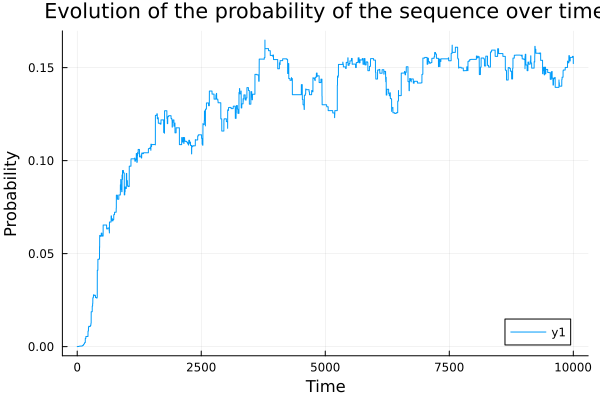

In [39]:
final_seq, p_struct_time_t=algo(seq, target_number, all_ctc_maps, 10000, 50)

using Plots

t=1:length(p_struct_time_t)

plot(t, p_struct_time_t, xlabel="Time", ylabel="Probability", title="Evolution of the probability of the sequence over time")

In [40]:
println(final_seq)
probability_target_structure(all_ctc_maps, final_seq, ttl_energy,target_number)

[16, 14, 18, 16, 5, 1, 1, 1, 18, 18, 5, 1, 19, 1, 1, 16, 19, 16, 19, 16, 18, 1, 16, 19, 1, 16, 16]


5.786588449875765e-16

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:29


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:27


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:26


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:27


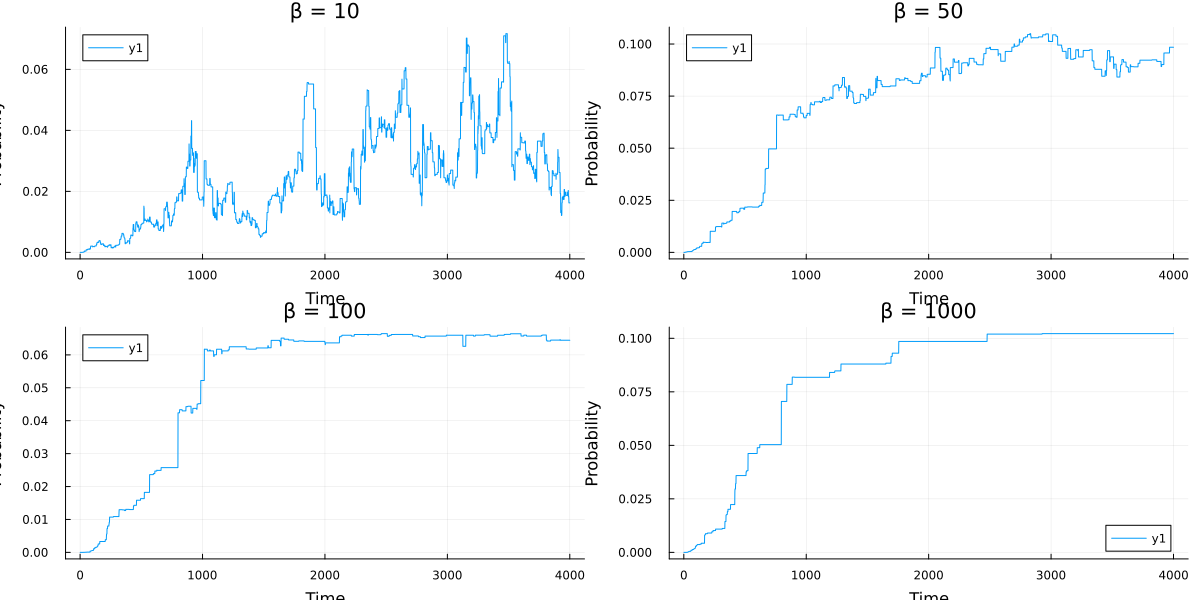

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([15, 9, 15, 16, 3, 1, 6, 4, 16, 18  …  18, 19, 16, 19, 3, 15, 19, …
  10.0   => ([11, 14, 14, 19, 4, 6, 7, 5, 16, 9  …  18, 13, 19, 14, 18, 18, 16,…
  1000.0 => ([19, 4, 15, 18, 3, 16, 19, 16, 16, 6  …  19, 15, 19, 16, 4, 17, 1,…
  100.0  => ([9, 8, 19, 16, 3, 19, 2, 8, 1, 4  …  1, 19, 16, 19, 18, 1, 1, 16, …

In [41]:
function benchmark_beta()
    betas = [10, 50, 100, 1000]
    results = Dict{Float64, Tuple{Vector{Int}, Vector{Float64}}}()
    plots = []

    for beta in betas
        println("Testing beta = $beta")
        final_seq, p_struct_time_t = algo(seq, target_number, all_ctc_maps, 4000, beta)
        results[beta] = (final_seq, p_struct_time_t)
        
        t = 1:length(p_struct_time_t)
        push!(plots, plot(t, p_struct_time_t, xlabel="Time", ylabel="Probability", 
                          title="β = $beta"))
    end

    fig = plot(plots..., layout=(2, 2), size=(1200, 600))
    display(fig)

    return results
end

benchmark_beta()

### Clusters de séquences

In [42]:
# retrieving the structures at different time points for beta=50
final_seq, p_struct_time_t, saved_structures = algo(seq, target_number, all_ctc_maps, 10000, 50, true, 2000)
println("On a sauvegardé $(length(saved_structures)) structures.")

algo (β=50) 100%|████████████████████████████████████████| Time: 0:01:11


On a sauvegardé 41 structures.


In [43]:
function hamming_distance(s1::Vector{Int}, s2::Vector{Int})
    return sum(s1 .!= s2)
end

hamming_distance (generic function with 1 method)

In [ ]:
function find_clusters(saved_structures::Dict{Int, Vector{Int}}, distance_threshold=3)
    epochs = sort(collect(keys(saved_structures))) # sort of epochs (increasing order)
    structures = [saved_structures[e] for e in epochs]
    n = length(structures)
    
    # calcul of all Hamming distances between saved structures
    distances = zeros(Int, n, n)
    for i in 1:n
        for j in i+1:n
            d = hamming_distance(structures[i], structures[j])
            distances[i,j] = d
            distances[j,i] = d
        end
    end

    # Clustering based on distance threshold
    cluster_id = collect(1:n)  # each structure has its own cluster at the beginning

    function find_root(x) 
        """ 
        Traceback function to find the cluster to wich a structure belongs to.
        """
        while cluster_id[x] != x 
            x = cluster_id[x]
        end
        return x
    end

    for i in 1:n
        for j in i+1:n
            if distances[i,j] <= distance_threshold # belong to the same cluster
                ri, rj = find_root(i), find_root(j)
                if ri != rj # if they are not already in the same cluster
                    cluster_id[ri] = rj  # merge clusters
                end
            end
        end
    end
    # We end up with a vector where each index points to the representative of its cluster (if cluster_id[5] = 3, then structure 5 and 3 are in the same cluster)

    # Gathering the results in a dict : key = index of the cluster, value = list of structures in the cluster
    clusters = Dict{Int, Vector{Vector{Int}}}()  # cluster_root => liste d'epochs
    for i in 1:n
        root = find_root(i)
        push!(get!(clusters, root, Vector{Int}[]), structures[i])
    end

    # Retrieving the mutated positions (loci) for each cluster
    cluster_loci = Dict{Int, Vector{Int}}()
    for (root, cluster_structs) in clusters
        if length(cluster_structs) > 1 # Verifing that there are more than 1 structure in the cluster

            ref = cluster_structs[1]
            differing_positions = Int[]
            for pos in 1:length(ref)
                if any(s[pos] != ref[pos] for s in cluster_structs) # we do not store which structure has this mutation, just if at least one is mutated
                    push!(differing_positions, pos)
                end
            end
            cluster_loci[root] = differing_positions
        end
    end

    return clusters, cluster_loci
end

find_clusters (generic function with 2 methods)

In [51]:
clusters, cluster_loci = find_clusters(saved_structures, 5)

println("Nombre de clusters $(length(clusters)) pour $(length(saved_structures)) structures sauvegardées.")

for (root, epochs) in clusters
    println("Cluster $root : avec $(length(epochs)) structure(s) :\n epochs = $epochs")
    if haskey(cluster_loci, root)
        println("  Loci touchés : $(cluster_loci[root])")
    end
    println()
end

Nombre de clusters 17 pour 41 structures sauvegardées.
Cluster 5 : avec 3 structure(s) :
 epochs = [[9, 18, 16, 15, 5, 1, 16, 19, 19, 4, 5, 5, 19, 5, 6, 14, 19, 16, 16, 19, 16, 15, 2, 17, 19, 5, 15], [9, 18, 16, 16, 5, 9, 16, 19, 18, 4, 5, 6, 19, 5, 6, 16, 19, 16, 16, 19, 16, 15, 2, 17, 19, 5, 15], [9, 19, 16, 16, 5, 6, 16, 19, 18, 4, 5, 3, 19, 5, 6, 16, 19, 15, 16, 19, 16, 15, 2, 17, 13, 5, 15]]
  Loci touchés : [2, 4, 6, 9, 12, 16, 18, 25]

Cluster 35 : avec 8 structure(s) :
 epochs = [[16, 1, 13, 16, 5, 1, 15, 18, 19, 2, 5, 5, 19, 1, 1, 16, 19, 16, 16, 19, 16, 16, 1, 16, 19, 4, 19], [16, 6, 10, 16, 3, 1, 16, 18, 19, 2, 5, 5, 19, 1, 1, 16, 19, 16, 16, 19, 16, 16, 1, 16, 19, 1, 19], [16, 10, 14, 16, 3, 1, 16, 18, 19, 2, 3, 5, 19, 1, 1, 16, 19, 16, 16, 19, 16, 16, 1, 16, 19, 1, 19], [16, 9, 13, 16, 3, 1, 16, 18, 19, 2, 5, 5, 19, 1, 1, 15, 19, 15, 16, 19, 16, 16, 1, 16, 19, 1, 19], [15, 2, 16, 16, 5, 1, 16, 18, 19, 1, 5, 4, 19, 1, 1, 16, 19, 15, 16, 19, 16, 16, 1, 16, 19, 1, 19], [15, 7

### Analyse fonctionnement algo

In [46]:
# Valeurs factices pour l'analyse
mut_test = (1, 2)                                    # Tuple{Int,Int}
seq_test = [1, 2, 3, 4, 5]                           # Vector{Int}
target_test = 1                                      # Int
weights_test = [1.0, 2.0, 3.0]                       # Vector{Float64}
pos_contacts_test = Dict(1 => [(1, 2), (1, 3)])      # Dict{Int, Vector{Tuple{Int,Int}}}
ttl_energy_test = 10.0                               # Float64
log_proba_test = -1.5                                # Float64

@code_warntype metropolis(mut_test, seq_test, target_test, weights_test, pos_contacts_test, ttl_energy_test, log_proba_test)

MethodInstance for metropolis(::Tuple{Int64, Int64}, ::Vector{Int64}, ::Int64, ::Vector{Float64}, ::Dict{Int64, Vector{Tuple{Int64, Int64}}}, ::Float64, ::Float64)
  from metropolis(mut, seq, target_number, all_ctc_maps, ttl_energy, old_prob, i) @ Main ~/Documents/master/m1/s2/projet/test_julia/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X51sZmlsZQ==.jl:1
Arguments
  #self#::Core.Const(Main.metropolis)
  mut::Tuple{Int64, Int64}
  seq::Vector{Int64}
  target_number::Int64
  all_ctc_maps::Vector{Float64}
  ttl_energy::Dict{Int64, Vector{Tuple{Int64, Int64}}}
  old_prob::Float64
  i::Float64
Body::Union{}
1 ─     (#self#)(mut, seq, target_number, all_ctc_maps, ttl_energy, old_prob, i, 1000)
└──     Core.Const(:(return %1))



In [47]:
seq_test = [1, 2, 3, 4, 5]
target_test = 1
maps_test = [Set([(1,2), (2,3)]), Set([(1,3)])]

@code_warntype algo(seq_test, target_test, maps_test)

MethodInstance for algo(::Vector{Int64}, ::Int64, ::Vector{Set{Tuple{Int64, Int64}}})
  from algo(seq, target_number, all_ctc_maps) @ Main ~/Documents/master/m1/s2/projet/test_julia/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X63sZmlsZQ==.jl:2
Arguments
  #self#::Core.Const(Main.algo)
  seq::Vector{Int64}
  target_number::Int64
  all_ctc_maps::Vector{Set{Tuple{Int64, Int64}}}
Body::Union{Tuple{Vector{Int64}, Vector{Float64}}, Tuple{Vector{Int64}, Vector{Float64}, Union{Nothing, Dict{Int64, Vector{Int64}}}}}
1 ─ %1 = (#self#)(seq, target_number, all_ctc_maps, 100, 100, false, 2000)::Union{Tuple{Vector{Int64}, Vector{Float64}}, Tuple{Vector{Int64}, Vector{Float64}, Union{Nothing, Dict{Int64, Vector{Int64}}}}}
└──      return %1



In [48]:
using BenchmarkTools

@benchmark algo($seq, $target_number, $all_ctc_maps)

ArgumentError: ArgumentError: Package BenchmarkTools not found in current path.
- Run `import Pkg; Pkg.add("BenchmarkTools")` to install the BenchmarkTools package.